In [5]:
import os

dataset_path = "/kaggle/input"  

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    if level < 12:
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 2:
            subindent = ' ' * 2 * (level + 1)
            for file in files[:5]:  
                print(f"{subindent}{file}")

input/
  datasets/
    mbkinaci/
      fruit-images-for-object-detection/
        train_zip/
          train/
        test_zip/
          test/


In [8]:
import os
import random

test_path = "/kaggle/input/datasets/mbkinaci/fruit-images-for-object-detection/test_zip/test"
train_path = "/kaggle/input/datasets/mbkinaci/fruit-images-for-object-detection/train_zip/train"

image_files = [f for f in os.listdir(test_path) if f.endswith('.jpg')]

print(f"Total images in test folder: {len(image_files)}")
print("Sample files:", image_files[:5])

Total images in test folder: 60
Sample files: ['apple_91.jpg', 'mixed_21.jpg', 'orange_83.jpg', 'orange_94.jpg', 'apple_80.jpg']


# **Preparation: Ground Truth Visualization** 

In [10]:
import xml.etree.ElementTree as ET

def parse_xml(xml_path):
    """
    Parses a Pascal VOC XML file and returns:
    - list of bounding boxes: [xmin, ymin, xmax, ymax]
    - list of class labels: ['apple', 'banana', ...]
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall('object'):
        label = obj.find('name').text          
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        labels.append(label)
        boxes.append([xmin, ymin, xmax, ymax])

    return boxes, labels

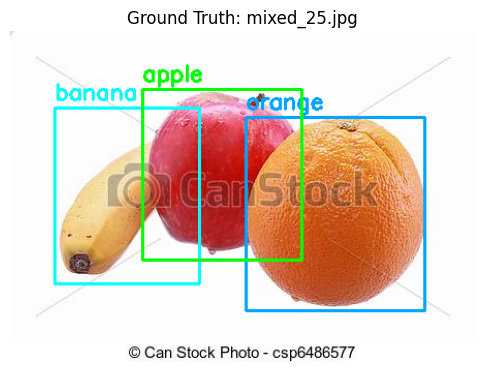

Image: mixed_25.jpg
Boxes: [[228, 83, 401, 270], [43, 74, 183, 244], [128, 56, 282, 221]]
Labels: ['orange', 'banana', 'apple']


In [11]:
import cv2
import matplotlib.pyplot as plt
import random

CLASS_COLORS = {
    'apple':  (0, 255, 0),    # green
    'banana': (0, 255, 255),  # yellow
    'orange': (0, 165, 255)   # orange
}

def visualize_ground_truth(image_folder):
    image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg')]
    random_image = random.choice(image_files)

    image_path = os.path.join(image_folder, random_image)
    xml_path   = os.path.join(image_folder, random_image.replace('.jpg', '.xml'))

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # convert for Matplotlib

    boxes, labels = parse_xml(xml_path)

    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        color = CLASS_COLORS.get(label, (255, 0, 0))  # default red if unknown

        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, thickness=2)

        cv2.putText(image, label,
                    (xmin, ymin - 8),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    fontScale=0.7,
                    color=color,
                    thickness=2)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Ground Truth: {random_image}")
    plt.axis('off')
    plt.show()

    print(f"Image: {random_image}")
    print(f"Boxes: {boxes}")
    print(f"Labels: {labels}")

visualize_ground_truth(test_path)

# **Task 1 - Core Concept: Intersection over Union (IoU)**

In [12]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two bounding boxes.
    Both boxes in [xmin, ymin, xmax, ymax] format.
    Returns a float between 0.0 and 1.0.
    """

    # Step 1: Intersection coordinates
    inter_xmin = max(box1[0], box2[0])
    inter_ymin = max(box1[1], box2[1])
    inter_xmax = min(box1[2], box2[2])
    inter_ymax = min(box1[3], box2[3])

    # Step 2: Intersection area (clamp to 0 if no overlap)
    inter_width  = max(0, inter_xmax - inter_xmin)
    inter_height = max(0, inter_ymax - inter_ymin)
    inter_area   = inter_width * inter_height

    # Step 3: Individual areas
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Step 4: Union area
    union_area = area1 + area2 - inter_area

    # Step 5: IoU
    if union_area == 0:
        return 0.0

    iou = inter_area / union_area
    return round(iou, 4)

In [13]:
# Case 1: Highly overlapping boxes
box1 = [10, 10, 100, 100]
box2 = [15, 15, 95, 95]
print(f"Case 1 (High overlap)    → IoU: {calculate_iou(box1, box2)}")

# Case 2: Partially overlapping boxes
box1 = [0, 0, 50, 50]
box2 = [25, 25, 75, 75]
print(f"Case 2 (Partial overlap) → IoU: {calculate_iou(box1, box2)}")

# Case 3: Completely disjoint boxes
box1 = [0, 0, 30, 30]
box2 = [50, 50, 100, 100]
print(f"Case 3 (No overlap)      → IoU: {calculate_iou(box1, box2)}")

Case 1 (High overlap)    → IoU: 0.7901
Case 2 (Partial overlap) → IoU: 0.1429
Case 3 (No overlap)      → IoU: 0.0


# **Task-2** 

In [15]:
import cv2
import matplotlib.pyplot as plt
import random
import os

image_files = [f for f in os.listdir(test_path) if f.endswith('.jpg')]
random_image = random.choice(image_files)

image_path = os.path.join(test_path, random_image)

image = cv2.imread(image_path)
print(f"Loaded image: {random_image}")
print(f"Image shape: {image.shape}")

Loaded image: orange_91.jpg
Image shape: (676, 800, 3)


In [16]:
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

ss.setBaseImage(image)

ss.switchToSelectiveSearchFast()

proposals = ss.process()

print(f"Total proposals generated: {len(proposals)}")

proposals_200 = proposals[:200]
print(f"Using first 200 proposals")

Total proposals generated: 883
Using first 200 proposals


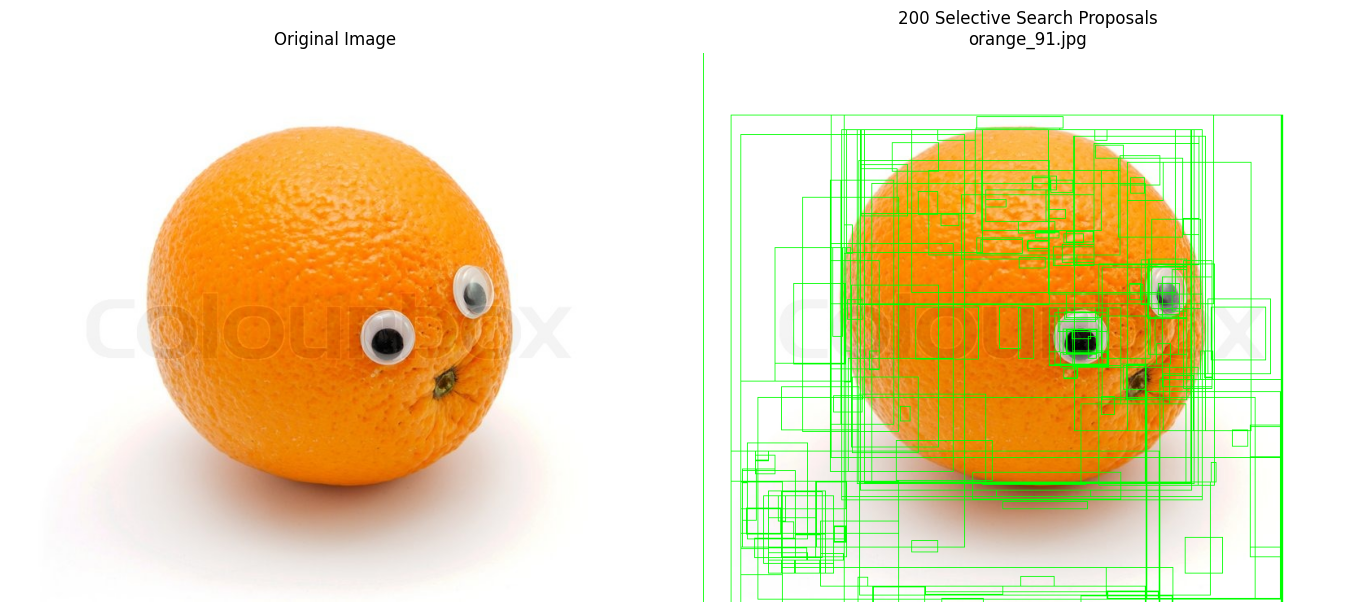

In [17]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_draw = image_rgb.copy()

for (x, y, w, h) in proposals_200:
    cv2.rectangle(image_draw,
                  (x, y),
                  (x + w, y + h),
                  color=(0, 255, 0),
                  thickness=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(image_draw)
axes[1].set_title(f"200 Selective Search Proposals\n{random_image}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [18]:
proposals_xyxy = []
for (x, y, w, h) in proposals_200:
    proposals_xyxy.append([x, y, x + w, y + h])

print(f"Converted {len(proposals_xyxy)} proposals to xyxy format")
print("Sample:", proposals_xyxy[:3])

Converted 200 proposals to xyxy format
Sample: [[np.int32(191), np.int32(420), np.int32(347), np.int32(528)], [np.int32(436), np.int32(314), np.int32(482), np.int32(331)], [np.int32(456), np.int32(103), np.int32(617), np.int32(465)]]


# **Task 3 - Implementing the R-CNN Bottleneck**

In [49]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import time

resnet18 = models.resnet18(pretrained=True)

feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-1])
feature_extractor.eval()  

print(resnet18.__class__.__name__, "loaded ✓")
print("Final layer removed — model now outputs feature vectors")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet loaded ✓
Final layer removed — model now outputs feature vectors


In [21]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    )
])

In [51]:
image_pil = Image.open(image_path).convert("RGB")

features_list = []

print("Starting R-CNN crop loop on 100 proposals...")

start_time = time.time()

for i, (xmin, ymin, xmax, ymax) in enumerate(proposals_xyxy[:100]):

    # Step A: Crop the region from original image
    crop = image_pil.crop((xmin, ymin, xmax, ymax))

    # Step B: Resize to 224x224 and normalize
    crop_tensor = transform(crop)                  # shape: [3, 224, 224]
    crop_tensor = crop_tensor.unsqueeze(0)         # add batch dim: [1, 3, 224, 224]

    # Step C: Pass through ResNet (no gradient needed)
    with torch.no_grad():
        features = feature_extractor(crop_tensor)  # shape: [1, 512, 1, 1]

    features_list.append(features)

end_time = time.time()

rcnn_time = end_time - start_time

print(f"\nProcessed 100 crops")
print(f"Total R-CNN time: {rcnn_time:.4f} seconds")
print(f"Average per crop: {(rcnn_time/100)*1000:.4f} ms")
print(f"Feature vector shape (single crop): {features_list[0].shape}")

Starting R-CNN crop loop on 100 proposals...

Processed 100 crops
Total R-CNN time: 3.6779 seconds
Average per crop: 36.7786 ms
Feature vector shape (single crop): torch.Size([1, 512, 1, 1])


# **Task 4 - Implementing Fast R-CNN (RoI Pooling)**

In [52]:
import torchvision.ops as ops

backbone = torch.nn.Sequential(*list(resnet18.children())[:-2])
backbone.eval()

print("Backbone ready (conv layers only) ✓")

Backbone ready (conv layers only) ✓


In [53]:
full_image_tensor = transform(image_pil)         # [3, 224, 224]
full_image_tensor = full_image_tensor.unsqueeze(0)  # [1, 3, 224, 224]

print(f"Input image tensor shape: {full_image_tensor.shape}")

with torch.no_grad():
    feature_map = backbone(full_image_tensor)    # single forward pass

print(f"Feature map shape: {feature_map.shape}")

Input image tensor shape: torch.Size([1, 3, 224, 224])
Feature map shape: torch.Size([1, 512, 7, 7])


In [25]:
# Spatial scale = feature map size / input image size
input_size    = 224
feature_size  = feature_map.shape[-1]   # e.g., 7

spatial_scale = feature_size / input_size

print(f"Input size:     {input_size}")
print(f"Feature size:   {feature_size}")
print(f"Spatial scale:  {spatial_scale:.5f}  (= 1/{int(1/spatial_scale)})")

Input size:     224
Feature size:   7
Spatial scale:  0.03125  (= 1/32)


In [54]:
roi_boxes = []
for (xmin, ymin, xmax, ymax) in proposals_xyxy[:100]:
    roi_boxes.append([0, xmin, ymin, xmax, ymax])

roi_tensor = torch.tensor(roi_boxes, dtype=torch.float32)

print(f"RoI tensor shape: {roi_tensor.shape}")
print(f"Sample row: {roi_tensor[0]}")

RoI tensor shape: torch.Size([100, 5])
Sample row: tensor([  0., 191., 420., 347., 528.])


In [57]:
print("Starting Fast R-CNN (RoI Pooling)...")

start_time = time.time()

with torch.no_grad():
    feature_map = backbone(full_image_tensor)

# RoI Pooling — extract 7x7 features for all 100 proposals at once
pooled_features = ops.roi_pool(
    input=feature_map,
    boxes=roi_tensor,
    output_size=(7, 7),
    spatial_scale=spatial_scale
)

end_time = time.time()

fast_rcnn_time = end_time - start_time

print(f"\nProcessed 100 RoIs")
print(f"Total Fast R-CNN time: {fast_rcnn_time:.4f} seconds")
print(f"Pooled features shape: {pooled_features.shape}")

Starting Fast R-CNN (RoI Pooling)...

Processed 100 RoIs
Total Fast R-CNN time: 0.0566 seconds
Pooled features shape: torch.Size([100, 512, 7, 7])


In [58]:
speedup = rcnn_time / fast_rcnn_time

print(f"  R-CNN time      : {rcnn_time:.4f} sec")
print(f"  Fast R-CNN time : {fast_rcnn_time:.4f} sec")
print(f"  Speedup         : {speedup:.1f}x faster")

  R-CNN time      : 3.6779 sec
  Fast R-CNN time : 0.0566 sec
  Speedup         : 65.0x faster


# **Task 5 - Faster R-CNN**

In [59]:
import torchvision.models.detection as detection
import torchvision.transforms.functional as F

faster_rcnn = detection.fasterrcnn_resnet50_fpn(pretrained=True)
faster_rcnn.eval()

print("Faster R-CNN loaded ✓")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Faster R-CNN loaded ✓


In [60]:
image_pil = Image.open(image_path).convert("RGB")

# Faster R-CNN only needs ToTensor — no resizing or normalization needed
image_tensor = F.to_tensor(image_pil)

print(f"Image tensor shape: {image_tensor.shape}")

Image tensor shape: torch.Size([3, 676, 800])


In [61]:
with torch.no_grad():
    predictions = faster_rcnn([image_tensor])

pred = predictions[0]

print(f"Total raw predictions: {len(pred['boxes'])}")
print(f"Sample boxes:  {pred['boxes'][:3]}")
print(f"Sample labels: {pred['labels'][:3]}")
print(f"Sample scores: {pred['scores'][:3]}")

Total raw predictions: 3
Sample boxes:  tensor([[173.2406,  94.3835, 628.0873, 520.7683],
        [  0.0000, 271.6407, 799.4899, 671.5762],
        [125.3780,  76.8795, 665.0411, 593.2440]])
Sample labels: tensor([55, 67, 51])
Sample scores: tensor([0.9936, 0.1400, 0.0838])


In [32]:
def filter_predictions(predictions, threshold=0.80):
    """
    Filter out predictions below confidence threshold.
    Returns filtered boxes, labels, scores.
    """
    pred    = predictions[0]
    boxes   = pred['boxes']
    labels  = pred['labels']
    scores  = pred['scores']

    # Boolean mask for scores above threshold
    keep    = scores >= threshold

    filtered_boxes  = boxes[keep]
    filtered_labels = labels[keep]
    filtered_scores = scores[keep]

    return filtered_boxes, filtered_labels, filtered_scores


filtered_boxes, filtered_labels, filtered_scores = filter_predictions(predictions)

print(f"Predictions after filtering (≥0.80): {len(filtered_boxes)}")

Predictions after filtering (≥0.80): 1


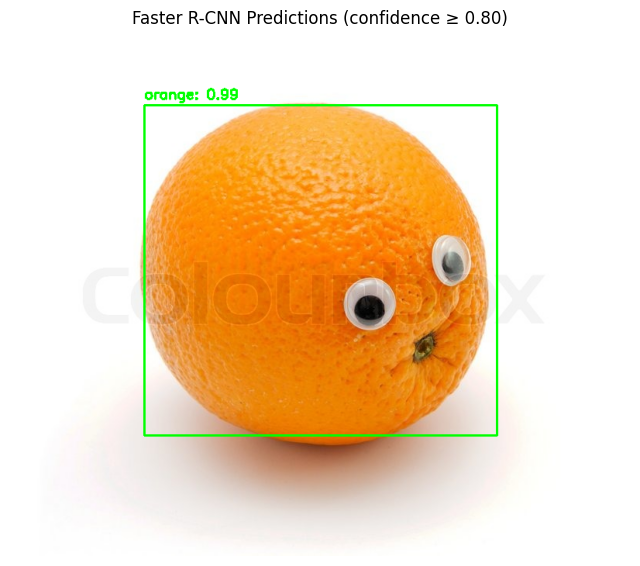

In [33]:
import numpy as np

COCO_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle',
    'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant',
    'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
    'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A',
    'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
    'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv',
    'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

def visualize_faster_rcnn(image_pil, boxes, labels, scores):
    image_np = np.array(image_pil).copy()

    for box, label, score in zip(boxes, labels, scores):
        xmin, ymin, xmax, ymax = box.int().tolist()
        class_name = COCO_NAMES[label.item()]
        confidence = score.item()

        # Draw box
        cv2.rectangle(image_np,
                      (xmin, ymin), (xmax, ymax),
                      color=(0, 255, 0), thickness=2)

        # Draw label + score
        text = f"{class_name}: {confidence:.2f}"
        cv2.putText(image_np, text,
                    (xmin, ymin - 8),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    fontScale=0.6,
                    color=(0, 255, 0),
                    thickness=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(image_np)
    plt.title(f"Faster R-CNN Predictions (confidence ≥ 0.80)")
    plt.axis('off')
    plt.show()


visualize_faster_rcnn(image_pil, filtered_boxes, filtered_labels, filtered_scores)

# **Task 6 - Non-Maximum Suppression (NMS)**

In [36]:
def non_maximum_suppression(boxes, scores, iou_threshold=0.5):

    sorted_indices = sorted(
        range(len(scores)),
        key=lambda i: scores[i],
        reverse=True
    )

    final_boxes  = []
    final_scores = []

    while len(sorted_indices) > 0:

        best_idx   = sorted_indices[0]
        best_box   = boxes[best_idx]
        best_score = scores[best_idx]

        final_boxes.append(best_box)
        final_scores.append(best_score)

        sorted_indices = sorted_indices[1:]

        remaining = []
        for idx in sorted_indices:
            iou = calculate_iou(best_box, boxes[idx])
            if iou <= iou_threshold:
                remaining.append(idx)

        sorted_indices = remaining

    return final_boxes, final_scores

In [37]:
test_boxes = [
    [10,  10, 100, 100],   # main box
    [12,  12, 102, 102],   # heavily overlaps with box 0
    [15,  15,  98,  98],   # heavily overlaps with box 0
    [200, 200, 300, 300],  # completely different object
    [205, 205, 305, 305],  # overlaps with box 3
]

test_scores = [0.95, 0.90, 0.85, 0.80, 0.75]

print("Before NMS:")
for i, (box, score) in enumerate(zip(test_boxes, test_scores)):
    print(f"  Box {i}: {box}  score: {score}")

kept_boxes, kept_scores = non_maximum_suppression(
    test_boxes, test_scores, iou_threshold=0.5
)

print(f"\nAfter NMS (threshold=0.5):")
for box, score in zip(kept_boxes, kept_scores):
    print(f"  Box: {box}  score: {score}")

print(f"\nReduced from {len(test_boxes)} → {len(kept_boxes)} boxes")

Before NMS:
  Box 0: [10, 10, 100, 100]  score: 0.95
  Box 1: [12, 12, 102, 102]  score: 0.9
  Box 2: [15, 15, 98, 98]  score: 0.85
  Box 3: [200, 200, 300, 300]  score: 0.8
  Box 4: [205, 205, 305, 305]  score: 0.75

After NMS (threshold=0.5):
  Box: [10, 10, 100, 100]  score: 0.95
  Box: [200, 200, 300, 300]  score: 0.8

Reduced from 5 → 2 boxes


In [62]:
pred = predictions[0]

raw_boxes  = pred['boxes'].tolist()
raw_scores = pred['scores'].tolist()

print(f"Before NMS: {len(raw_boxes)} boxes")

nms_boxes, nms_scores = non_maximum_suppression(
    raw_boxes, raw_scores, iou_threshold=0.5
)

print(f"After NMS:  {len(nms_boxes)} boxes")

Before NMS: 3 boxes
After NMS:  2 boxes


# **Task 7 - YOLO Fine-Tuning**

In [39]:
!pip install ultralytics -q

from ultralytics import YOLO
print("Ultralytics loaded ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics loaded ✓


In [40]:
import yaml

dataset_yaml = {
    'path': '/kaggle/working/fruit_dataset',
    'train': 'train/images',
    'val':   'test/images',
    'test':  'test/images',
    'nc': 3,
    'names': ['apple', 'banana', 'orange']
}

with open('/kaggle/working/fruit.yaml', 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print("dataset.yaml created ✓")

dataset.yaml created ✓


In [42]:
import os
import xml.etree.ElementTree as ET
import shutil
from PIL import Image

CLASS_MAP = {'apple': 0, 'banana': 1, 'orange': 2}

def convert_xml_to_yolo(xml_path, image_path, output_label_path):
    """Convert Pascal VOC XML to YOLO txt format."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    width  = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    if width == 0 or height == 0:
        with Image.open(image_path) as img:
            width, height = img.size

    lines = []
    for obj in root.findall('object'):
        name = obj.find('name').text.lower()
        if name not in CLASS_MAP:
            continue

        class_id = CLASS_MAP[name]
        bndbox   = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height
        w        = (xmax - xmin) / width
        h        = (ymax - ymin) / height

        lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

    with open(output_label_path, 'w') as f:
        f.write('\n'.join(lines))


def prepare_yolo_dataset(src_folder, dst_images, dst_labels):
    """Copy images and convert XML labels."""
    os.makedirs(dst_images, exist_ok=True)
    os.makedirs(dst_labels, exist_ok=True)

    image_files = [f for f in os.listdir(src_folder) if f.endswith('.jpg')]

    for img_file in image_files:
        xml_file = img_file.replace('.jpg', '.xml')

        img_src = os.path.join(src_folder, img_file)
        xml_src = os.path.join(src_folder, xml_file)

        if not os.path.exists(xml_src):
            continue

        shutil.copy(img_src, os.path.join(dst_images, img_file))

        label_dst = os.path.join(dst_labels, img_file.replace('.jpg', '.txt'))
        convert_xml_to_yolo(xml_src, img_src, label_dst)

    print(f"✓ Prepared {len(image_files)} images → {dst_images}")


prepare_yolo_dataset(
    train_path,
    '/kaggle/working/fruit_dataset/train/images',
    '/kaggle/working/fruit_dataset/train/labels'
)

prepare_yolo_dataset(
    test_path,
    '/kaggle/working/fruit_dataset/test/images',
    '/kaggle/working/fruit_dataset/test/labels'
)

✓ Prepared 240 images → /kaggle/working/fruit_dataset/train/images
✓ Prepared 60 images → /kaggle/working/fruit_dataset/test/images


In [43]:
model = YOLO('yolov8n.pt')

results = model.train(
    data    = '/kaggle/working/fruit.yaml',
    epochs  = 10,
    imgsz   = 416,
    batch   = 16,
    name    = 'fruit_yolov8',
    project = '/kaggle/working/runs'
)

print("Training complete ✓")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fruit.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

In [44]:
metrics = model.val(
    data = '/kaggle/working/fruit.yaml',
    split = 'test'
)

print(f"\nmAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 817.5±694.2 MB/s, size: 42.7 KB)
val: Scanning /kaggle/working/fruit_dataset/test/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 21.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.2it/s 1.2s0.5s
                   all         60        117      0.882      0.743      0.873      0.632
                 apple         24         35      0.936      0.837      0.918      0.745
                banana         22         40       0.79      0.725       0.81      0.504
                orange         22         42      0.921      0.667      0.892      0.647
Speed: 2.2ms preprocess, 10.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/


image 1/1 /kaggle/working/fruit_dataset/test/images/banana_88.jpg: 320x416 1 banana, 40.8ms
Speed: 1.3ms preprocess, 40.8ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 416)


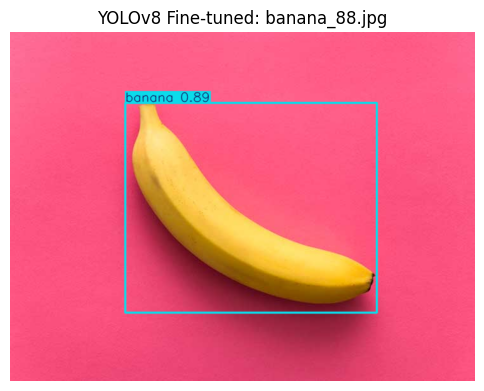


image 1/1 /kaggle/working/fruit_dataset/test/images/banana_87.jpg: 192x416 4 bananas, 42.5ms
Speed: 1.0ms preprocess, 42.5ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 416)


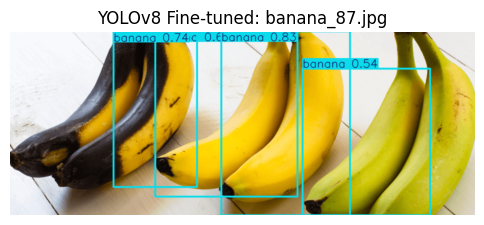


image 1/1 /kaggle/working/fruit_dataset/test/images/apple_95.jpg: 288x416 5 apples, 41.1ms
Speed: 1.3ms preprocess, 41.1ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 416)


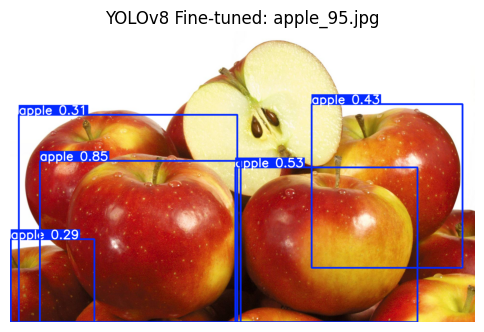

In [45]:
import glob

test_images = random.sample(
    glob.glob('/kaggle/working/fruit_dataset/test/images/*.jpg'), 3
)

finetuned_model = YOLO('/kaggle/working/runs/fruit_yolov8/weights/best.pt')

for img_path in test_images:
    result = finetuned_model(img_path)[0]

    result_img = result.plot()   # returns numpy array with boxes drawn
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(result_img_rgb)
    plt.title(f"YOLOv8 Fine-tuned: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()


image 1/1 /kaggle/working/fruit_dataset/test/images/banana_93.jpg: 416x416 2 bananas, 5.8ms
Speed: 1.2ms preprocess, 5.8ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 416)


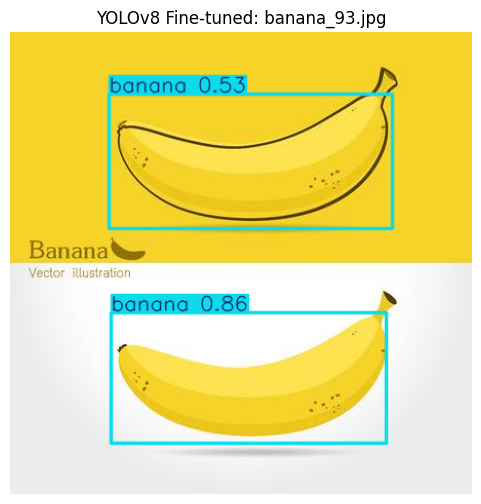


image 1/1 /kaggle/working/fruit_dataset/test/images/banana_82.jpg: 288x416 1 banana, 7.4ms
Speed: 1.3ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 416)


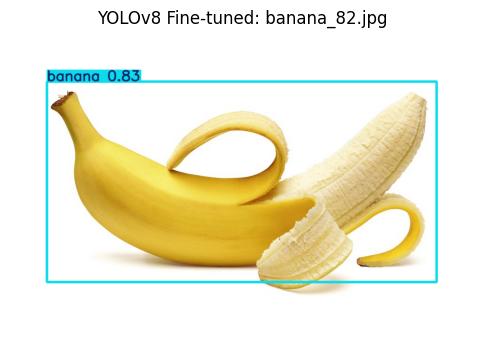


image 1/1 /kaggle/working/fruit_dataset/test/images/banana_90.jpg: 256x416 4 bananas, 41.3ms
Speed: 1.2ms preprocess, 41.3ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 416)


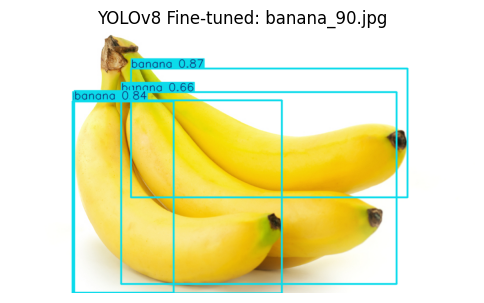

In [46]:
import glob

test_images = random.sample(
    glob.glob('/kaggle/working/fruit_dataset/test/images/*.jpg'), 3
)

finetuned_model = YOLO('/kaggle/working/runs/fruit_yolov8/weights/best.pt')

for img_path in test_images:
    result = finetuned_model(img_path)[0]

    result_img = result.plot()   # returns numpy array with boxes drawn
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(result_img_rgb)
    plt.title(f"YOLOv8 Fine-tuned: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()

In [47]:
import time
import torch
import numpy as np

times = []
for _ in range(5):   
    start = time.time()
    with torch.no_grad():
        pred = faster_rcnn([image_tensor])
    times.append((time.time() - start) * 1000)

frcnn_time = np.mean(times)

frcnn_boxes  = pred[0]['boxes']
frcnn_scores = pred[0]['scores']
frcnn_total  = len(frcnn_scores)
frcnn_kept   = (frcnn_scores >= 0.80).sum().item()

print(f"Faster R-CNN inference : {frcnn_time:.1f} ms")
print(f"Faster R-CNN detections (≥0.80): {frcnn_kept}/{frcnn_total}")

yolo_pretrained = YOLO('yolov8n.pt')

times = []
for _ in range(5):
    start = time.time()
    _ = yolo_pretrained(image_path, verbose=False)
    times.append((time.time() - start) * 1000)

yolo_pre_time = np.mean(times)
print(f"\nYOLO pretrained inference: {yolo_pre_time:.1f} ms")


finetuned_model = YOLO('/kaggle/working/runs/fruit_yolov8/weights/best.pt')

times = []
for _ in range(5):
    start = time.time()
    _ = finetuned_model(image_path, verbose=False)
    times.append((time.time() - start) * 1000)

yolo_ft_time = np.mean(times)

metrics = finetuned_model.val(
    data  = '/kaggle/working/fruit.yaml',
    split = 'test',
    verbose = False
)

yolo_ft_map50    = metrics.box.map50
yolo_ft_map5095  = metrics.box.map
yolo_ft_precision = metrics.box.mp
yolo_ft_recall   = metrics.box.mr

print(f"YOLO fine-tuned inference : {yolo_ft_time:.1f} ms")
print(f"YOLO fine-tuned mAP@50    : {yolo_ft_map50:.4f}")
print(f"YOLO fine-tuned mAP@50-95 : {yolo_ft_map5095:.4f}")
print(f"YOLO fine-tuned Precision : {yolo_ft_precision:.4f}")
print(f"YOLO fine-tuned Recall    : {yolo_ft_recall:.4f}")

Faster R-CNN inference : 2957.6 ms
Faster R-CNN detections (≥0.80): 1/3

YOLO pretrained inference: 46.5 ms
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1610.8±930.5 MB/s, size: 73.3 KB)
val: Scanning /kaggle/working/fruit_dataset/test/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 21.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.2it/s 1.2s0.5s
                   all         60        117      0.882      0.743      0.873      0.632
Speed: 1.4ms preprocess, 6.2ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2
YOLO fine-tuned inference : 29.2 ms
YOLO fine-tuned mAP@50    : 0.8732
YOLO fine-tuned mAP@50-95 : 0.6320
YOLO fine-tuned Precision : 0.8824
YOLO fine-tuned Recall    : 0.7430


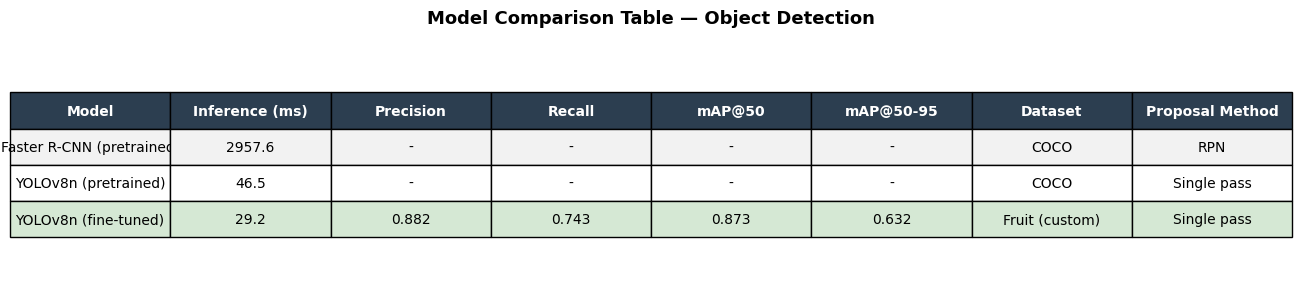

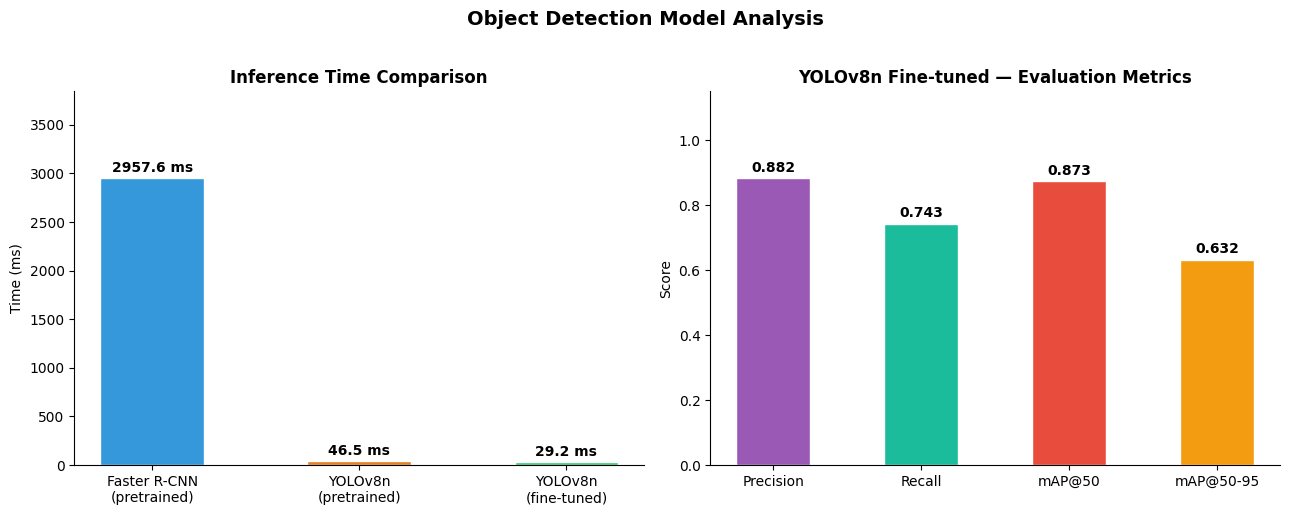

✓ Saved: comparison_table.png
✓ Saved: comparison_charts.png


In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

data = {
    'Model': [
        'Faster R-CNN\n(pretrained)',
        'YOLOv8n\n(pretrained)',
        'YOLOv8n\n(fine-tuned)'
    ],
    'Inference (ms)' : [frcnn_time,    yolo_pre_time,    yolo_ft_time],
    'Precision'      : ['-',           '-',              f"{yolo_ft_precision:.3f}"],
    'Recall'         : ['-',           '-',              f"{yolo_ft_recall:.3f}"],
    'mAP@50'         : ['-',           '-',              f"{yolo_ft_map50:.3f}"],
    'mAP@50-95'      : ['-',           '-',              f"{yolo_ft_map5095:.3f}"],
    'Dataset'        : ['COCO',        'COCO',           'Fruit (custom)'],
    'Proposal Method': ['RPN',         'Single pass',    'Single pass'],
}

fig, ax = plt.subplots(figsize=(13, 3))
ax.axis('off')

columns = ['Model', 'Inference (ms)', 'Precision', 'Recall',
           'mAP@50', 'mAP@50-95', 'Dataset', 'Proposal Method']

cell_data = []
for i in range(3):
    row = [
        data['Model'][i].replace('\n', ' '),
        f"{data['Inference (ms)'][i]:.1f}",
        data['Precision'][i],
        data['Recall'][i],
        data['mAP@50'][i],
        data['mAP@50-95'][i],
        data['Dataset'][i],
        data['Proposal Method'][i],
    ]
    cell_data.append(row)

table = ax.table(
    cellText   = cell_data,
    colLabels  = columns,
    cellLoc    = 'center',
    loc        = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.2)

for j in range(len(columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

row_colors = ['#f2f2f2', '#ffffff', '#d5e8d4']
for i in range(1, 4):
    for j in range(len(columns)):
        table[i, j].set_facecolor(row_colors[i - 1])

plt.title('Model Comparison Table — Object Detection',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/kaggle/working/comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models      = ['Faster R-CNN\n(pretrained)', 'YOLOv8n\n(pretrained)', 'YOLOv8n\n(fine-tuned)']
inf_times   = [frcnn_time, yolo_pre_time, yolo_ft_time]
colors      = ['#3498db', '#e67e22', '#2ecc71']

bars = axes[0].bar(models, inf_times, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Inference Time Comparison', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Time (ms)')
axes[0].set_ylim(0, max(inf_times) * 1.3)
for bar, val in zip(bars, inf_times):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(inf_times)*0.02,
                 f'{val:.1f} ms', ha='center', fontsize=10, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)


metric_names  = ['Precision', 'Recall', 'mAP@50', 'mAP@50-95']
metric_values = [yolo_ft_precision, yolo_ft_recall, yolo_ft_map50, yolo_ft_map5095]
metric_colors = ['#9b59b6', '#1abc9c', '#e74c3c', '#f39c12']

bars2 = axes[1].bar(metric_names, metric_values,
                    color=metric_colors, width=0.5, edgecolor='white')
axes[1].set_title('YOLOv8n Fine-tuned — Evaluation Metrics', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.15)
for bar, val in zip(bars2, metric_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Object Detection Model Analysis', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/comparison_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: comparison_table.png")
print("✓ Saved: comparison_charts.png")